<a href="https://colab.research.google.com/github/shiva123786/FUTURE_DS_03/blob/master/Student%20FeedBack%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

In [4]:
data=pd.read_excel("/content/Student_Satisfaction_Survey.xls")
data1=pd.read_excel("/content/student_feedback.xls")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Student_Satisfaction_Survey.xls'

In [5]:
data

NameError: name 'data' is not defined

In [6]:
data1

NameError: name 'data1' is not defined

In [7]:
df=pd.concat([data,data1],axis=1)

NameError: name 'data' is not defined

In [8]:
df.fillna(0,inplace=True)

NameError: name 'df' is not defined

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

id_col = 'Student ID'
non_numeric_cols = ['Questions', 'Average/ Percentage', 'Course Name', 'Basic Course']
rating_cols = [c for c in df.columns if c not in ['Unnamed: 0', id_col] + non_numeric_cols]
# Convert columns in rating_cols to numeric, coercing errors to NaN
for col in rating_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Drop columns with all NaN values after conversion if any
df.dropna(axis=1, how='all', inplace=True)
# Update rating_cols to reflect columns that are now numeric
rating_cols = [c for c in df.columns if c not in ['Unnamed: 0', id_col] + non_numeric_cols]

NameError: name 'df' is not defined

In [ ]:
avg_scores = df[rating_cols].mean().sort_values(ascending=False)
print('Average scores:\n', avg_scores)

In [ ]:
# Plot average ratings
plt.figure(figsize=(10,5))
sns.barplot(x=avg_scores.values, y=avg_scores.index)
plt.title('Average Rating per Feedback Question')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()

In [10]:
# Correlation heatmap
plt.figure(figsize=(10,8))
corr = df[rating_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation between feedback aspects')
plt.show()

NameError: name 'df' is not defined

<Figure size 1000x800 with 0 Axes>

In [11]:
# distribution plots for each rating question (boxplots + histograms)
for c in rating_cols:
    fig, axes = plt.subplots(1,2, figsize=(12,3.5))
    sns.boxplot(x=df[c], ax=axes[0])
    axes[0].set_title(f'Boxplot: {c}')
    sns.histplot(df[c].dropna(), bins=10, kde=False, ax=axes[1])
    axes[1].set_title(f'Histogram: {c}')
    plt.tight_layout()
    plt.show()

NameError: name 'rating_cols' is not defined

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
/tmp/ipython-input-3941911692.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_vader', data=comments, order=['positive', 'neutral', 'negative'], palette='viridis')


sentiment_vader
positive    0.7
negative    0.2
neutral     0.1
Name: proportion, dtype: float64


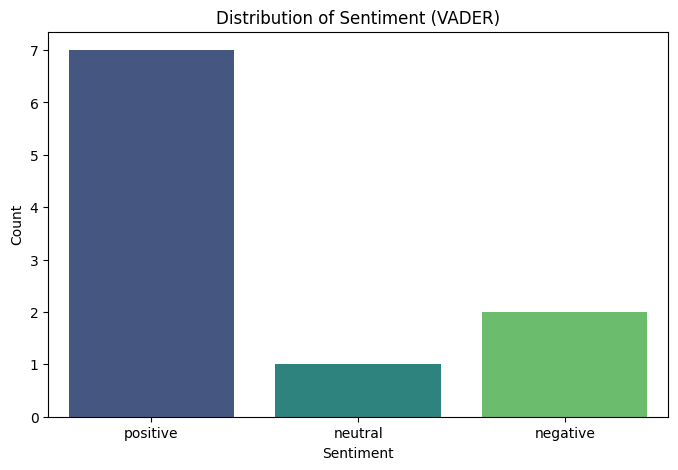

In [12]:
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')


comments = pd.read_csv('/content/above sheet can add comments also plz - above sheet can add comments also plz.csv')
text_col = 'Feedback'

# TextBlob polarity
comments['polarity'] = comments[text_col].astype(str).apply(lambda t: TextBlob(t).sentiment.polarity)

# VADER compound score
sid = SentimentIntensityAnalyzer()
comments['vader_compound'] = comments[text_col].astype(str).apply(lambda t: sid.polarity_scores(t)['compound'])

# Classify
comments['sentiment_textblob'] = comments['polarity'].apply(lambda x: 'positive' if x>0.05 else ('negative' if x<-0.05 else 'neutral'))
comments['sentiment_vader'] = comments['vader_compound'].apply(lambda x: 'positive' if x>=0.05 else ('negative' if x<=-0.05 else 'neutral'))

# Quick summary
print(comments['sentiment_vader'].value_counts(normalize=True))

# Plot VADER sentiment distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment_vader', data=comments, order=['positive', 'neutral', 'negative'], palette='viridis')
plt.title('Distribution of Sentiment (VADER)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()